### Python Packages & Libraries

In [ ]:
# Import the python packages & libraries
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Read In Dataset

In [ ]:
# Utilize the Pandas library to create a dataframe (df) to visualize our data at a high level
df = pd.read_csv('medical_clean.csv')

# Preview the dataframe (displaying all columns)
pd.set_option("display.max_columns", None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


### Data Preparation

In [ ]:
# Review dataset column data types, value counts and total rows/columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [ ]:
# Check for missing values in our dataset
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [ ]:
# Summary statistics for continuous variables to check for outliers
continuous_summary = df[['Age', 'Income', 'Children', 'VitD_levels', 'Doc_visits',
    'Full_meals_eaten', 'vitD_supp', 'Initial_days',
    'TotalCharge', 'Additional_charges']].describe()
continuous_summary

,Age,Income,Children,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Initial_days,TotalCharge,Additional_charges
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.511700,40490.495160,2.097200,17.964262,5.012200,1.001400,0.398900,34.455299,5312.172769,12934.528587
std,20.638538,28521.153293,2.163659,2.017231,1.045734,1.008117,0.628505,26.309341,2180.393838,6542.601544
min,18.000000,154.080000,0.000000,9.806483,1.000000,0.000000,0.000000,1.001981,1938.312067,3125.703000
25%,36.000000,19598.775000,0.000000,16.626439,4.000000,0.000000,0.000000,7.896215,3179.374015,7986.487755
50%,53.000000,33768.420000,1.000000,17.951122,5.000000,1.000000,0.000000,35.836244,5213.952000,11573.977735
75%,71.000000,54296.402500,3.000000,19.347963,6.000000,2.000000,1.000000,61.161020,7459.699750,15626.490000
max,89.000000,207249.100000,10.000000,26.394449,9.000000,7.000000,5.000000,71.981490,9180.728000,30566.070000


In [ ]:
# Check for outliers in our Income data by looking at the largest and smallest values
income_largest = df['Income'].nlargest(30)
income_smallest = df['Income'].nsmallest(30)

print("LOWEST PATIENT INCOMES (Low to High):\n", income_smallest.to_string(index=False))
print("\nHIGHEST PATIENT INCOMES (High to Low):\n", income_largest.to_string(index=False))

LOWEST PATIENT INCOMES (Low to High):
  154.08
 300.79
 395.23
 401.86
 493.04
 695.22
 702.16
 798.98
 826.01
 881.07
 881.40
 953.74
1048.43
1078.12
1196.72
1209.56
1277.08
1286.25
1301.34
1366.98
1380.70
1392.23
1402.22
1409.92
1453.90
1480.67
1482.85
1486.44
1528.80
1541.63

HIGHEST PATIENT INCOMES (High to Low):
 207249.10
204542.41
203774.60
197675.00
197576.18
196915.60
194796.24
190110.80
189416.27
189129.92
186791.40
186752.00
183037.10
179543.70
178945.40
178470.63
174745.85
171680.20
171288.05
171031.20
170961.50
167286.62
167105.10
166702.70
166048.50
166017.39
165588.50
165560.97
165329.55
164123.69


In [ ]:
# Check data types of variables
df.dtypes

CaseOrder               int64
Customer_id            object
Interaction            object
UID                    object
City                   object
State                  object
County                 object
Zip                     int64
Lat                   float64
Lng                   float64
Population              int64
Area                   object
TimeZone               object
Job                    object
Children                int64
Age                     int64
Income                float64
Marital                object
Gender                 object
ReAdmis                object
VitD_levels           float64
Doc_visits              int64
Full_meals_eaten        int64
vitD_supp               int64
Soft_drink             object
Initial_admin          object
HighBlood              object
Stroke                 object
Complication_risk      object
Overweight             object
Arthritis              object
Diabetes               object
Hyperlipidemia         object
BackPain  

In [ ]:
# Cast Income column data type from float to integer
df["Income"] = df["Income"].astype(int)

In [ ]:
# Reduce column precision down to 2 decimal places to better reflect USD pricing and improve readability
df["TotalCharge"] = df.TotalCharge.round(2)
df["Additional_charges"] = df.TotalCharge.round(2)
df["VitD_levels"] = df.VitD_levels.round(2)

In [ ]:
# Subset the dataset, selecting only the columns relevant to our research question
relevant_columns = [
    "Age",
    "Income",
    "VitD_levels",
    "Doc_visits",
    "Initial_days",
    "Full_meals_eaten",
    "TotalCharge",
    "Additional_charges",
    "Children",
    "vitD_supp"
]

df_subset = df[relevant_columns]

# Preview the resulting dataframe
df_subset

,Age,Income,VitD_levels,Doc_visits,Initial_days,Full_meals_eaten,TotalCharge,Additional_charges,Children,vitD_supp
0,53,86575,19.14,6,10.585770,0,3726.70,3726.70,1,0
1,51,46805,18.94,4,15.129562,2,4193.19,4193.19,3,1
2,53,14370,18.06,4,4.772177,1,2434.23,2434.23,3,0
3,78,39741,16.58,4,1.714879,1,2127.83,2127.83,0,0
4,22,1209,17.44,5,1.254807,0,2113.07,2113.07,1,2
...,...,...,...,...,...,...,...,...,...,...
9995,25,45967,16.98,4,51.561220,2,6850.94,6850.94,2,1
9996,87,14983,18.18,5,68.668240,0,7741.69,7741.69,4,0
9997,45,65917,17.13,4,70.154180,2,8276.48,8276.48,3,0
9998,43,29702,19.91,5,63.356900,2,7644.48,7644.48,3,1


### C2. Variable Standardization

In [ ]:
# Variable Standardization

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_data = scaler.fit_transform(df_subset)

# Convert scaled data to a DataFrame
df_scaled = pd.DataFrame(scaled_data, columns=df_subset.columns)

# Check the means and standard deviations
print("Column Means:\n", df_scaled.mean())
print("\nColumn Standard Deviations:\n", df_scaled.std())

Column Means:
 Age                   1.147527e-16
Income                7.389644e-17
VitD_levels          -5.561773e-16
Doc_visits            3.161915e-17
Initial_days         -1.818989e-16
Full_meals_eaten     -7.815970e-17
TotalCharge           9.094947e-17
Additional_charges    9.094947e-17
Children              5.506706e-17
vitD_supp             3.694822e-17
dtype: float64

Column Standard Deviations:
 Age                   1.00005
Income                1.00005
VitD_levels           1.00005
Doc_visits            1.00005
Initial_days          1.00005
Full_meals_eaten      1.00005
TotalCharge           1.00005
Additional_charges    1.00005
Children              1.00005
vitD_supp             1.00005
dtype: float64


### Cleaned Dataset

In [ ]:
# Save the transformed dataset as a CSV file
df_subset.to_csv('d212_task2_transformed_medical_clean.csv', index=False)

print(f"The final cleaned and scaled dataset has been saved as:\n 'd212_task2_transformed_medical_clean.csv'")

The final cleaned and scaled dataset has been saved as:
 'd212_task2_transformed_medical_clean.csv'


### D1. Matrix of all Principal Components

In [ ]:
# Determine the matrix of all the principal components

# Perform PCA
pca = PCA()
pca_components = pca.fit_transform(df_scaled)

# Create a DataFrame for PCA components
df_pca = pd.DataFrame(pca_components, columns=[f'PC{i+1}' for i in range(pca_components.shape[1])])
print(df_pca.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.394175 -0.781262  0.717999  1.344205 -0.825324  0.095322 -0.386778   
1 -1.007013  0.535903 -0.085415 -0.221186  0.690230 -0.559306  1.477619   
2 -2.160123  0.650647 -0.933919 -0.465136  0.761887 -0.192652 -0.542437   
3 -2.409252  0.009420 -0.590140 -0.915494  0.240073  1.451923 -0.046108   
4 -2.387166 -1.556694  0.262325 -1.910294 -0.341102 -2.093849  0.304140   

        PC8       PC9          PC10  
0  1.277356 -0.153340  2.835348e-16  
1 -0.094865 -0.179924  2.285423e-16  
2  0.018224  0.152329 -2.417986e-16  
3  0.887192  0.167808  7.874683e-17  
4 -1.212219  0.162838 -4.918607e-17  


### D2. Total Number of Principal Components

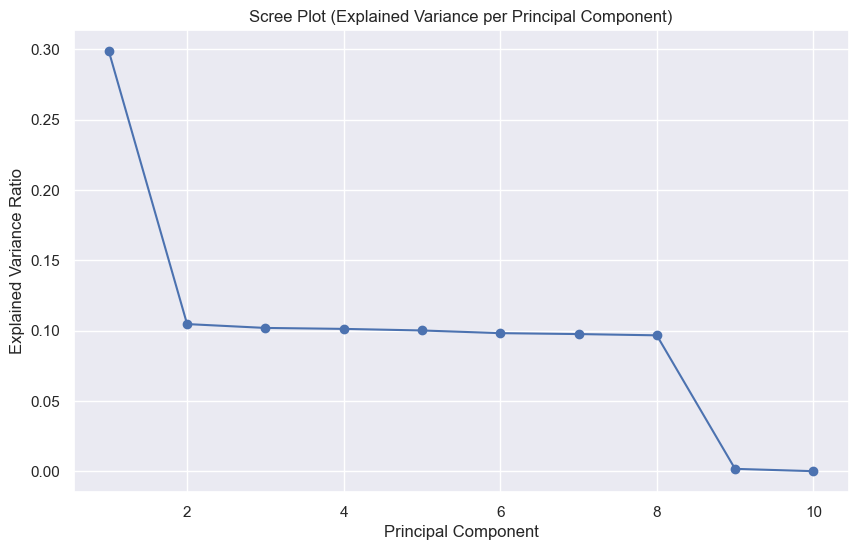

In [ ]:
# Identify the total number of principal components using the elbow rule

# Explained variance ratio = variance explained by each component
explained_variance = pca.explained_variance_ratio_

# Scree plot (Elbow Rule)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title('Scree Plot (Explained Variance per Principal Component)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

### D3. Variance of Each Principal Component

In [ ]:
# Identify the variance of each of the retained principal components

# Variance ratio (proportion of total variance explained)
explained_variance_ratio = pca.explained_variance_ratio_

# Variance of the retained components
num_components = 2

# Individual variance
for i in range(num_components):
    print(f"PC{i+1} explains {explained_variance_ratio[i] * 100:.2f}% of the total variance")

PC1 explains 29.86% of the total variance
PC2 explains 10.46% of the total variance


### D4. Total Variance of Principal Components

In [ ]:
# Cumulative variance
total_cumulative_variance = explained_variance_ratio[:num_components].sum()
print(f"Together, the first {num_components} principal components explain {total_cumulative_variance * 100:.2f}% of the total variance.")

Together, the first 2 principal components explain 40.32% of the total variance.
